# 3 — Proposed Hybrid CNN-BiGRU-Attention Model
**Author:** Revanth Katari

Trains the proposed architecture:

```
LLM Sentence Embeddings  →  CNN Feature Extraction  →  BiGRU Sequential Modeling  →  Sequential Attention  →  Classification
```

This combines:
- **Pretrained LLM embeddings** (`all-MiniLM-L6-v2`, 384-dim) for rich semantic representation
- **CNN** (multi-kernel) for extracting local linguistic patterns across sentences
- **BiGRU** for capturing long-range bidirectional dependencies
- **Sequential Attention** for interpretability and focusing on informative segments

In [1]:
import sys, os, json
sys.path.insert(0, os.path.join(os.pardir, "src"))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from config import (
    EMBEDDINGS_CACHE, LABELS_CACHE, MODELS_DIR, RESULTS_DIR,
    EMBEDDING_DIM, MAX_SENTENCES, HIDDEN_DIM, NUM_CLASSES,
    NUM_LAYERS, DROPOUT, NUM_FILTERS, KERNEL_SIZES,
    BATCH_SIZE, LEARNING_RATE, WEIGHT_DECAY,
    NUM_EPOCHS, PATIENCE, RANDOM_SEED,
)
from data_utils import create_splits, make_dataloader
from models import HybridCNNBiGRUAttention
from train_utils import train_one_epoch, evaluate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

Device: cuda


In [2]:
embeddings = np.load(EMBEDDINGS_CACHE)
if embeddings.dtype == np.float16:
    embeddings = embeddings.astype(np.float32)
labels = np.load(LABELS_CACHE)

X_train, X_val, X_test, y_train, y_val, y_test = create_splits(
    embeddings, labels, seed=RANDOM_SEED
)

train_loader = make_dataloader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_dataloader(X_val, y_val, BATCH_SIZE, shuffle=False)
test_loader  = make_dataloader(X_test, y_test, BATCH_SIZE, shuffle=False)

print(f"Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}")

Train: 50,465  Val: 10,815  Test: 10,815


## 3.1 Model instantiation

In [3]:
model = HybridCNNBiGRUAttention(
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
    use_cnn=True,
    use_attention=True,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {train_params:,}")
print(model)

Total parameters:     1,012,162
Trainable parameters: 1,012,162
HybridCNNBiGRUAttention(
  (convs): ModuleList(
    (0): Sequential(
      (0): Conv1d(384, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): Conv1d(384, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (2): Sequential(
      (0): Conv1d(384, 64, kernel_size=(7,), stride=(1,), padding=(3,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (gru): GRU(192, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): SequentialAttention(
    (W): Linear(in_features=256, out_features=256, bias=True)
    (v): Linear(in_features=256, out_features=1, bias=False)
  )
  (dropou

## 3.2 Training

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": [], "val_auc": []}
best_f1, wait = 0.0, 0
save_path = os.path.join(MODELS_DIR, "hybrid_cnn_bigru_attn.pt")

for epoch in range(1, NUM_EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    v_loss, v_met, _, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step(v_loss)

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_met["accuracy"])
    history["val_f1"].append(v_met["f1"])
    history["val_auc"].append(v_met["auc"])

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  "
          f"TrLoss={t_loss:.4f} TrAcc={t_acc:.4f}  "
          f"ValLoss={v_loss:.4f} ValAcc={v_met['accuracy']:.4f} "
          f"ValF1={v_met['f1']:.4f} ValAUC={v_met['auc']:.4f}")

    if v_met["f1"] > best_f1:
        best_f1 = v_met["f1"]
        torch.save(model.state_dict(), save_path)
        print(f"  -> Saved best model (F1={best_f1:.4f})")
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch 01/20  TrLoss=0.1956 TrAcc=0.9215  ValLoss=0.1298 ValAcc=0.9515 ValF1=0.9515 ValAUC=0.9893
  -> Saved best model (F1=0.9515)
Epoch 02/20  TrLoss=0.0980 TrAcc=0.9636  ValLoss=0.1145 ValAcc=0.9572 ValF1=0.9572 ValAUC=0.9926
  -> Saved best model (F1=0.9572)
Epoch 03/20  TrLoss=0.0588 TrAcc=0.9795  ValLoss=0.1020 ValAcc=0.9629 ValF1=0.9629 ValAUC=0.9938
  -> Saved best model (F1=0.9629)
Epoch 04/20  TrLoss=0.0368 TrAcc=0.9875  ValLoss=0.1273 ValAcc=0.9640 ValF1=0.9640 ValAUC=0.9938
  -> Saved best model (F1=0.9640)
Epoch 05/20  TrLoss=0.0256 TrAcc=0.9909  ValLoss=0.1268 ValAcc=0.9647 ValF1=0.9647 ValAUC=0.9939
  -> Saved best model (F1=0.9647)
Epoch 06/20  TrLoss=0.0223 TrAcc=0.9922  ValLoss=0.1372 ValAcc=0.9650 ValF1=0.9650 ValAUC=0.9938
  -> Saved best model (F1=0.9650)
Epoch 07/20  TrLoss=0.0074 TrAcc=0.9976  ValLoss=0.1762 ValAcc=0.9650 ValF1=0.9650 ValAUC=0.9942
Epoch 08/20  TrLoss=0.0044 TrAcc=0.9987  ValLoss=0.1921 ValAcc=0.9671 ValF1=0.9671 ValAUC=0.9944
  -> Saved best mode

## 3.3 Training curves

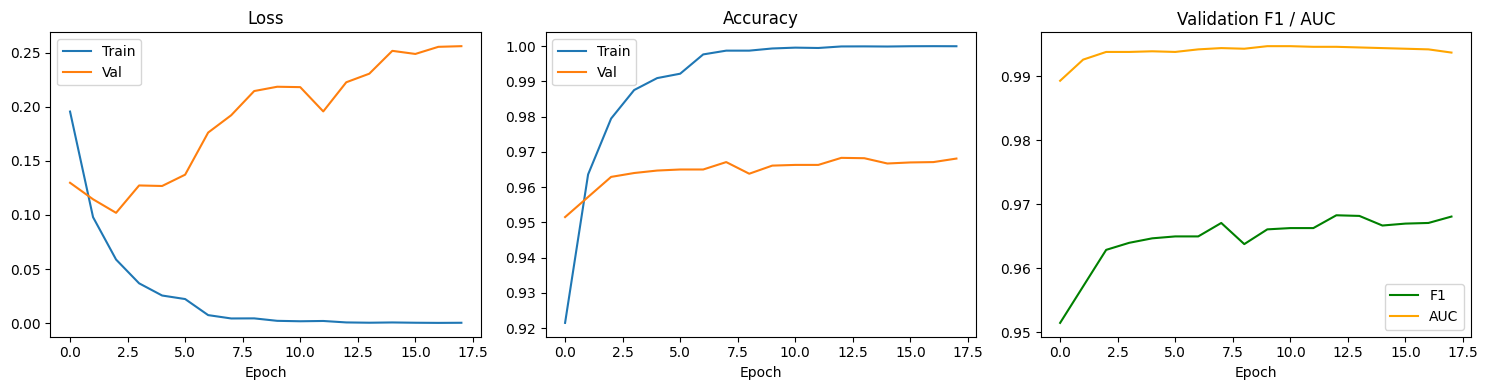

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Val")
axes[1].set_title("Accuracy"); axes[1].legend()

axes[2].plot(history["val_f1"], label="F1", color="green")
axes[2].plot(history["val_auc"], label="AUC", color="orange")
axes[2].set_title("Validation F1 / AUC"); axes[2].legend()

for ax in axes:
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

## 3.4 Test evaluation

In [6]:
model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
_, test_metrics, preds, probs, true_labels = evaluate(model, test_loader, criterion, device)

print("Test Metrics:")
for k, v in test_metrics.items():
    print(f"  {k:>10s}: {v:.4f}")

with open(os.path.join(RESULTS_DIR, "hybrid_cnn_bigru_attn_metrics.json"), "w") as f:
    json.dump({"test": test_metrics, "history": history}, f, indent=2)
print("\nResults saved.")

Test Metrics:
    accuracy: 0.9667
   precision: 0.9667
      recall: 0.9667
          f1: 0.9667
         auc: 0.9938

Results saved.


## 3.5 Confusion matrix

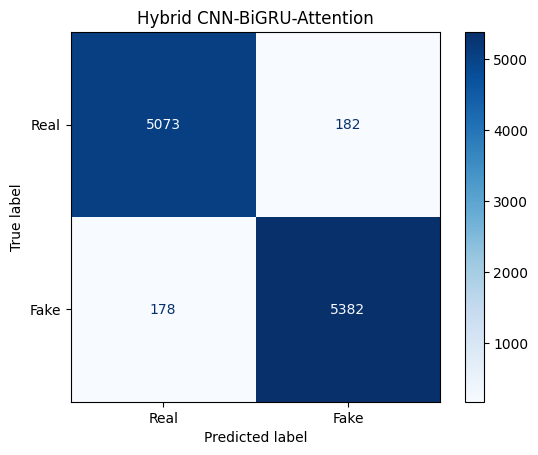

              precision    recall  f1-score   support

        Real       0.97      0.97      0.97      5255
        Fake       0.97      0.97      0.97      5560

    accuracy                           0.97     10815
   macro avg       0.97      0.97      0.97     10815
weighted avg       0.97      0.97      0.97     10815



In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(true_labels, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"])
disp.plot(cmap="Blues")
plt.title("Hybrid CNN-BiGRU-Attention")
plt.show()

print(classification_report(true_labels, preds, target_names=["Real", "Fake"]))